In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt

In [2]:
# Set parameters in the Hamiltonianin unit of f=GF/sqrt(2)/V
angle = 26.56/180.*np.pi #Sin(2*angle)=0.8
wbar = 0.0   #dm**2/(4*T*f)
tbar = 0.0   #T/f

In [3]:
prefix = 'pub/arXiv2404_16690/'

# infile = prefix + 'Nn6'        # Input filename  
# initj = 3   # n=6 nitial state

infile = prefix + 'Nn8'      # Input filename  
initj = 13   # n=8 nitial state

#infile = prefix + 'Nn10'      # Input filename  
#initj = 15   # n=8 nitial state

dt = 0.01               # Time step size
Nt = 300#1000              # Total time steps

In [8]:
# load momentum points from grid
mom_grid_points = []
with open(infile+'_p.dat', 'r') as f:
    for lines in f.readlines():
        l = [x for x in lines.split(' ')]
        if l[0] == '#':
            pass
        else:
            lf = [np.float64(x) for x in lines.split(' ')]
            mom_grid_points.append(lf)

mom_grid_points = np.array(mom_grid_points)
K = len(mom_grid_points)
Nb = 2 * K
print(f'Number of momentum modes: {K}')

Number of momentum modes: 35


In [9]:
K

35

In [10]:
mom_grid_points

array([[ 1., -4.,  0.],
       [ 2., -4.,  0.],
       [ 3., -4.,  0.],
       [ 1., -3.,  0.],
       [ 2., -3.,  0.],
       [ 3., -3.,  0.],
       [ 4., -3.,  0.],
       [ 1., -2.,  0.],
       [ 2., -2.,  0.],
       [ 3., -2.,  0.],
       [ 4., -2.,  0.],
       [ 1., -1.,  0.],
       [ 2., -1.,  0.],
       [ 3., -1.,  0.],
       [ 4., -1.,  0.],
       [ 1.,  0.,  0.],
       [ 2.,  0.,  0.],
       [ 3.,  0.,  0.],
       [ 4.,  0.,  0.],
       [ 5.,  0.,  0.],
       [ 1.,  1.,  0.],
       [ 2.,  1.,  0.],
       [ 3.,  1.,  0.],
       [ 4.,  1.,  0.],
       [ 1.,  2.,  0.],
       [ 2.,  2.,  0.],
       [ 3.,  2.,  0.],
       [ 4.,  2.,  0.],
       [ 1.,  3.,  0.],
       [ 2.,  3.,  0.],
       [ 3.,  3.,  0.],
       [ 4.,  3.,  0.],
       [ 1.,  4.,  0.],
       [ 2.,  4.,  0.],
       [ 3.,  4.,  0.]])

In [11]:
infile+'_s.dat'

'pub/arXiv2404_16690/Nn8_s.dat'

In [12]:
# List states

states = []

with open(infile+'_s.dat', 'r') as f:
    for lines in f.readlines():
        l = [int(x) for x in lines.split(' ')]
        nstate = int(2**len(l)/4**(len(l)-len(list(set(l)))))
        rp = []
        if nstate < 2**len(l):
            for i in range(len(l)-1):
                if l[i]==l[i+1]:
                    rp.append(l[i])
        nrp = [x for x in l if x not in rp]
        numnrp = len(nrp)
        for i in range(nstate):
            state = []
            for j in range(len(rp)):
                state.append(2*rp[j])
                state.append(2*rp[j]+1)
            for j in range(numnrp):
                state.append(2*nrp[j]+(i//2**(numnrp-j-1))%2)
            states.append(sorted(state))

In [13]:
states

[[0, 10, 20, 24, 40, 50, 56, 66],
 [0, 10, 20, 24, 40, 50, 56, 67],
 [0, 10, 20, 24, 40, 50, 57, 66],
 [0, 10, 20, 24, 40, 50, 57, 67],
 [0, 10, 20, 24, 40, 51, 56, 66],
 [0, 10, 20, 24, 40, 51, 56, 67],
 [0, 10, 20, 24, 40, 51, 57, 66],
 [0, 10, 20, 24, 40, 51, 57, 67],
 [0, 10, 20, 24, 41, 50, 56, 66],
 [0, 10, 20, 24, 41, 50, 56, 67],
 [0, 10, 20, 24, 41, 50, 57, 66],
 [0, 10, 20, 24, 41, 50, 57, 67],
 [0, 10, 20, 24, 41, 51, 56, 66],
 [0, 10, 20, 24, 41, 51, 56, 67],
 [0, 10, 20, 24, 41, 51, 57, 66],
 [0, 10, 20, 24, 41, 51, 57, 67],
 [0, 10, 20, 25, 40, 50, 56, 66],
 [0, 10, 20, 25, 40, 50, 56, 67],
 [0, 10, 20, 25, 40, 50, 57, 66],
 [0, 10, 20, 25, 40, 50, 57, 67],
 [0, 10, 20, 25, 40, 51, 56, 66],
 [0, 10, 20, 25, 40, 51, 56, 67],
 [0, 10, 20, 25, 40, 51, 57, 66],
 [0, 10, 20, 25, 40, 51, 57, 67],
 [0, 10, 20, 25, 41, 50, 56, 66],
 [0, 10, 20, 25, 41, 50, 56, 67],
 [0, 10, 20, 25, 41, 50, 57, 66],
 [0, 10, 20, 25, 41, 50, 57, 67],
 [0, 10, 20, 25, 41, 51, 56, 66],
 [0, 10, 20, 2

In [39]:
""" I added this """
num_l = 0
num_repeat = 0
repeats = []
with open(infile+'_s.dat', 'r') as f:
    for lines in f.readlines():
        num_l += 1
        l = [int(x) for x in lines.split(' ')]
        if len(l) != len(set(l)):
            num_repeat += 1
            repeats.append(l)

In [40]:
Nn = len(l)
bstr_to_j = {}
j_to_bstr = {}
Ns = len(states)
for i in range(Ns):
    b = ','.join(str(int(x)) for x in states[i])
    bstr_to_j[b] = i 
    j_to_bstr[i] = b


print(f'The number of basis states: {Ns}')
print(f'The number of neutrinos: {Nn}')

The number of basis states: 6528
The number of neutrinos: 8


In [41]:
# Input is a state's binary representation, return its basis index j
def b_to_j(b):
    oc = []
    for i in range(Nb):
        if b[i]==1:
            oc.append(i)
    bstr = ','.join(str(x) for x in oc)
    return bstr_to_j[bstr]

# Input is the basis index j, and returns its binary representation
def j_to_b(j):
    bstr = j_to_bstr[j]
    oc = [int(x) for x in bstr.split(',')]
    b = [0]*Nb
    for i in range(len(oc)):
        b[oc[i]] = 1
    return b

In [42]:
# Given neutrino's mode index and flavor, return its bin number k = K*flavor + p
def bin(p, flavor):
    return 2*p + flavor

# given bin index (0 - Nb-1), returns momenta(index) and flavor
def pf(i):
    return i//2, i%2

In [43]:
# Applying a*(b1)a(b2) to a basis state, b = [b1,b2]
def quad(b, basis):
    basis_copy = basis.copy()
    l = 1
    f = 1.0
    if basis_copy[b[1]] == 0:
        l = 0
    else:
        basis_copy[b[1]] = 0
        f = f * (-1)**np.sum(basis_copy[:b[1]])
    if basis_copy[b[0]] ==1:
        l = 0
    else:
        basis_copy[b[0]] = 1
        f = f * (-1)**np.sum(basis_copy[:b[0]])
    return l, f, basis_copy

In [44]:
# Applying a*(b1)a*(b2)a(b3)a(b4) to state, b = [b1,b2,b3,b4]
def quar(b, basis):
    basis_copy = basis.copy()
    l = 1
    f = 1.0
    if basis_copy[b[3]] == 0:
        l = 0
    else:
        basis_copy[b[3]] = 0
        f = f * (-1)**np.sum(basis_copy[:b[3]])
    if basis_copy[b[2]] == 0:
        l = 0
    else:
        basis_copy[b[2]] = 0
        f = f * (-1)**np.sum(basis_copy[:b[2]])
    if basis_copy[b[1]] ==1:
        l = 0
    else:
        basis_copy[b[1]] = 1
        f = f * (-1)**np.sum(basis_copy[:b[1]])
    if basis_copy[b[0]] ==1:
        l = 0
    else:
        basis_copy[b[0]] = 1
        f = f * (-1)**np.sum(basis_copy[:b[0]])

    return l, f, basis_copy

In [45]:
# mass term applied to basis state j.
def mass(j):
    sin = j_to_b(j)
    state = np.zeros(Ns) * 1j
    for p in range(K):
        ke = bin(p, 0)
        km = bin(p, 1)
        absp = np.sqrt(np.sum(P[p]*P[p]))
        factor_ee = tbar*absp - np.cos(2*angle)*wbar/absp
        factor_mm = tbar*absp + np.cos(2*angle)*wbar/absp
        factor_em = np.sin(2*angle)*wbar/absp
        factor_me = factor_em
        t, fa, sout = quad([ke, ke], sin)
        # e -> e
        if t == 1:
            state[b_to_j(sout)] += fa * factor_ee 
        t, fa, sout = quad([km, km], sin) 
        # mu -> mu
        if t == 1:
            state[b_to_j(sout)] += fa * factor_mm 
        # mu -> e 
        t, fa, sout = quad([ke, km], sin) 
        if t == 1:
            state[b_to_j(sout)] += fa * factor_em 
        # e -> mu
        t, fa, sout = quad([km, ke], sin) 
        if t == 1:
            state[b_to_j(sout)] += fa * factor_me 

    return state

In [46]:
flavor_pair = np.array([[0,0],[0,1],[1,0],[1,1]]) # flavor (alpha, beta)

In [47]:
# Input is 3-dim momentum, returns |p|, theta and phi (0-2pi)
def p_spherical(p):
    absp = np.sqrt(np.sum(p*p))
    theta = np.arctan2(np.sqrt(p[0]**2+p[1]**2), p[2])
    phi = np.arctan2(p[1],p[0])
    return absp, theta, phi

# # g factor for H_vv
# def g_factor(p1, p2, q1, q2):
#     absp1, tp1, pp1 = p_spherical(p1)
#     absp2, tp2, pp2 = p_spherical(p2)
#     absq1, tq1, pq1 = p_spherical(q1)
#     absq2, tq2, pq2 = p_spherical(q2)
#     fac1 = np.exp(-1j*pq1)*np.sin(tq1/2.)*np.cos(tq2/2.) - np.exp(-1j*pq2)*np.cos(tq1/2.)*np.sin(tq2/2.)
#     fac2 = np.exp(1j*pp1)*np.sin(tp1/2.)*np.cos(tp2/2.) - np.exp(1j*pp2)*np.cos(tp1/2.)*np.sin(tp2/2.)
#     return 2 * fac1 * fac2

def g_factor(p1, p2, q1, q2):
    absp1, tp1, pp1 = p_spherical(p1)
    absp2, tp2, pp2 = p_spherical(p2)
    absq1, tq1, pq1 = p_spherical(q1)
    absq2, tq2, pq2 = p_spherical(q2)
    fac1 = np.exp(-1j*pq1)*np.sin(tq1/2.)*np.cos(tq2/2.) - np.exp(-1j*pq2)*np.cos(tq1/2.)*np.sin(tq2/2.)
    fac2 = np.exp(1j*pp1)*np.sin(tp1/2.)*np.cos(tp2/2.) - np.exp(1j*pp2)*np.cos(tp1/2.)*np.sin(tp2/2.)
    if ((p1==q1).all() and (p2==q2).all()) or ((p1==q2).all() and (p2==q1).all()):
        res = 2 * fac1 * fac2
    else:
        res = 0
    return res

In [ ]:
print(f'Creating the list of conserved 4 momenta')
momenta4 = []
gfactors = []
for i1 in range(K):
    p1 = P[i1]
    for i2 in range(K):
        p2 = P[i2]
        for i3 in range(K):
            p3 = P[i3]
            for i4 in range(K):
                p4 = P[i4]
                pdiff = p1+p2-p3-p4
                if np.sum(np.abs(pdiff)) < 1e-7:
                    k1 = np.sqrt(np.sum(p1*p1))
                    k2 = np.sqrt(np.sum(p2*p2))
                    k3 = np.sqrt(np.sum(p3*p3))
                    k4 = np.sqrt(np.sum(p4*p4))
                    gfactor = g_factor(p1,p2,p3,p4)
                    if np.abs(k1+k2-k3-k4) < 1e-7 and np.abs(gfactor) > 1e-7:
                        momenta4.append([i1, i2, i3, i4])
                        gfactors.append(gfactor)
# 

momenta4 = np.array(momenta4)
gfactors = np.array(gfactors)
print(f'Number of conserved P and conserved E pairs: {len(momenta4)}')  

# full 4 fermi interaction term applied to basis state j.
# a*(p1,fp1)a*(p2,fp2)a(q1,fq1)a(q2,fq2) with p1+p2 = q1+q2
def vv_full(j):
    sin = j_to_b(j)
    state = np.zeros(Ns) * 1j
    for i in range(len(momenta4)):
        p1 = momenta4[i,0]
        p2 = momenta4[i,1]
        q1 = momenta4[i,2]
        q2 = momenta4[i,3] 
        factor = - gfactors[i]
        for f in range(4):
            i1 = bin(p1, flavor_pair[f,0])
            i2 = bin(p2, flavor_pair[f,1])
            i3 = bin(q1, flavor_pair[f,0])
            i4 = bin(q2, flavor_pair[f,1])
            t, fa, sout = quar([i1, i2, i3, i4], sin)
            if t == 1:
                state[b_to_j(sout)] += fa * factor
    return state

In [ ]:
Ns

In [ ]:
H = np.zeros((Ns, Ns))*1j

for i in range(Ns):
    column = np.zeros(Ns)*1j
    H[:,i] += mass(i)
    H[:,i] += vv_full(i)
    if i%100==0:
        print(f'constructing {i}th column of the Hamiltonian')

# Diaginalize H and construct time evolution operator U
# Full Hamiltonian
hvals, hvecs = np.linalg.eigh(H) 
U = hvecs @ np.diag(np.exp(-dt*hvals*1j)) @ hvecs.conj().T

In [ ]:
# norm and observables of interest
def norm(state):
    return np.sqrt(np.sum(state * state.conj()))

# input is the state vector, returns the # of neutrino in each bin (Nb)
def observable(state):
    obs = np.zeros(Nb)
    for i in range(Ns):
        binary = j_to_b(i)
        obs += np.abs(state[i])**2*np.array(binary)
    return obs

# returns string of time and wave function amplitude
def print_cstr(state,i):
    return str(i*dt) + ' ' + ' '.join([str(x) for x in state]) 

# returns string of time and occupation number per bin
def print_nstr(state,i):
    obs = observable(state)
    return str(i*dt) + ' ' + ' '.join([str(x) for x in obs]) 


# Time evolution from the initial state j    
state = np.zeros(Ns)*1j
state[initj] = 1.0

In [31]:
init_state = state

In [32]:
state = np.zeros(Ns)*1j
state[initj] = 1.0

init_state = state

times = []
# echo_6 = []
# echo_8 = []
echo_6_trunc = []
# echo_8_trunc = []

times.append(0)
# echo_6.append(np.abs(state @ init_state)**2)
# echo_8.append(np.abs(state @ init_state)**2)
echo_6_trunc.append(np.abs(state @ init_state)**2)
# echo_8_trunc.append(np.abs(state @ init_state)**2)

for i in range(1, Nt+1):
    state = U @ state
    n = norm(state)
    if abs(n-1.) > 1e-5:
        print('Norm off by > 1e-5 at time ', i*dt)
        break
    print('-'*30)
    print(np.abs(state @ init_state)**2)
    times.append(i*dt)
    # echo_6.append(np.abs(state @ init_state)**2)
    # echo_8.append(np.abs(state @ init_state)**2)
    echo_6_trunc.append(np.abs(state @ init_state)**2)
    # echo_8_trunc.append(np.abs(state @ init_state)**2)

------------------------------
0.9949584217585714
------------------------------
0.9799941281120231
------------------------------
0.9555811235924324
------------------------------
0.9224854203229108
------------------------------
0.8817304213473686
------------------------------
0.8345511241123394
------------------------------
0.7823396156511327
------------------------------
0.7265847724900111
------------------------------
0.6688093451747515
------------------------------
0.6105076853732587
------------------------------
0.553087260597162
------------------------------
0.49781680766959124
------------------------------
0.4457835224572931
------------------------------
0.3978611012123597
------------------------------
0.35468977691681236
------------------------------
0.3166687760782819
------------------------------
0.2839609033159937
------------------------------
0.25650828761576766
------------------------------
0.23405773616756445
------------------------------
0.21619367347075

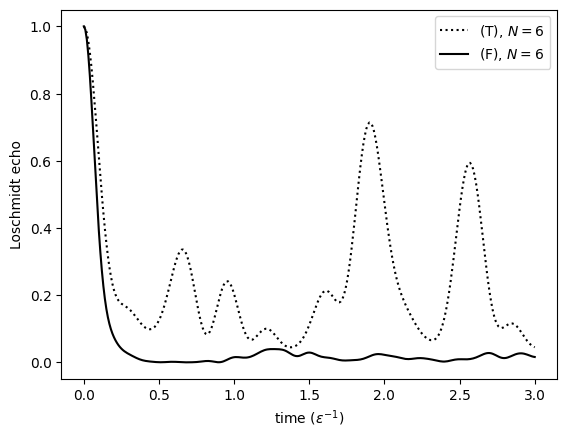

In [33]:
plt.plot(times, echo_6_trunc, color = 'black', label='(T), $N=6$', linestyle='dotted')
# plt.plot(times, echo_8_trunc, color = 'blue', label='(T), $N=8$', linestyle='dotted')
plt.plot(times, echo_6, color = 'black', label='(F), $N=6$')
# plt.plot(times, echo_8, color = 'blue', label='(F), $N=8$')
plt.xlabel('time ($\\epsilon^{-1}$)')
plt.ylabel('Loschmidt echo')
plt.legend()
plt.savefig('fig_7.pdf')
plt.show()